<a href="https://colab.research.google.com/github/Developer-Abnam/machine-learning-zoomcamp-2025-solutions/blob/main/module6_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports for this project

In [1]:
import pandas as pd
import numpy as np


import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
!wget $data

--2025-11-03 14:16:54--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv.7’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.03s   

2025-11-03 14:16:54 (28.7 MB/s) - ‘car_fuel_efficiency.csv.7’ saved [874188/874188]



## Previewing the CSV File

In [3]:
df = pd.read_csv(data)
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


# Filling missing values

In [4]:
df.isna().sum()

,0
engine_displacement,0
num_cylinders,482
horsepower,708
vehicle_weight,0
acceleration,930
model_year,0
origin,0
fuel_type,0
drivetrain,0
num_doors,502


In [5]:
df_fill = df.fillna(0)
df_fill

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,0.0,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,0.0,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,0.0,15.101802
9700,180,0.0,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


**Splitting Data**

In [6]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df_fill, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

**Turning the dataframe intro matrices**

In [7]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

train_dicts = df_train.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)
X_val = dv.transform(val_dicts)
X_train

array([[1.39000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 2.96667950e+03],
       [1.71000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.95082212e+03],
       [1.74000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 3.07822167e+03],
       ...,
       [1.67000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 0.00000000e+00, 3.04196459e+03],
       [1.52000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 0.00000000e+00, 2.45334143e+03],
       [1.41000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 2.83389943e+03]])

# Question 1

**Decision Tree**

In [8]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import roc_auc_score

[Text(0.5, 0.75, 'vehicle_weight <= 3022.107\nsquared_error = 6.398\nsamples = 5822\nvalue = 14.994'),
 Text(0.25, 0.25, 'squared_error = 2.575\nsamples = 3034\nvalue = 16.882'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 2.453\nsamples = 2788\nvalue = 12.938'),
 Text(0.625, 0.5, '  False')]

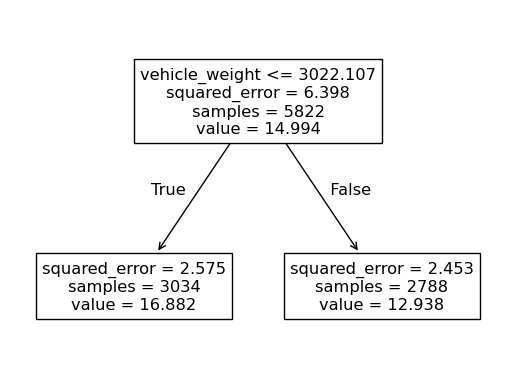

In [9]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)
features_names = dv.get_feature_names_out().tolist()
plot_tree(dt, feature_names=features_names)

# Question 2

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error as RMSE

In [11]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
RMSE(y_val, y_pred)

0.4599777557336149

# Question 3

In [12]:
scores = []
for n in np.arange(10, 201, 10):
  rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_val)
  rmse = RMSE(y_val, y_pred)
  scores.append((n, rmse))
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
df_scores.head()

,n_estimators,rmse
0,10,0.459978
1,20,0.453659
2,30,0.450743
3,40,0.448007
4,50,0.446151


# Question 4

In [13]:
scores = []
for d in [10, 15, 20, 25]:
  for n in np.arange(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = RMSE(y_val, y_pred)
    scores.append((n, d, rmse))
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'max_depth', 'rmse'])
df_scores.head()

,n_estimators,max_depth,rmse
0,10,10,0.451895
1,20,10,0.448719
2,30,10,0.446225
3,40,10,0.443877
4,50,10,0.442682


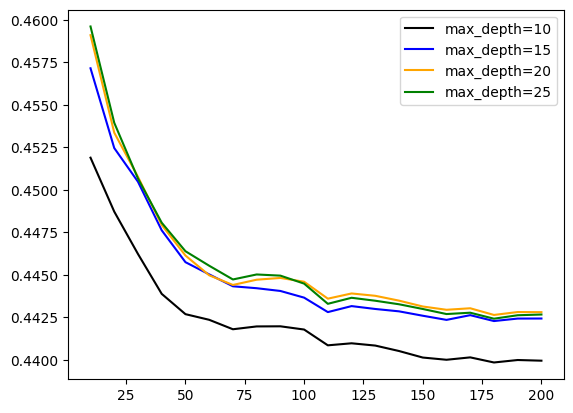

In [17]:
colors = ['black', 'blue', 'orange', 'green']
max_depths = [10, 15, 20, 25]
for d, c in zip(max_depths, colors) :
  df_subset = df_scores[df_scores['max_depth'] == d]

  plt.plot(df_subset.n_estimators, df_subset.rmse, color= c, label='max_depth=%s' % d)
  plt.legend()

# Question 5

In [18]:
rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [19]:
pd.DataFrame(rf.feature_importances_, index=features_names, columns=['feature_importance']).sort_values('feature_importance', ascending=False)

,feature_importance
vehicle_weight,0.959162
horsepower,0.016040
acceleration,0.011471
engine_displacement,0.003269
model_year,0.003182
num_cylinders,0.002359
num_doors,0.001591
origin=USA,0.000555
origin=Europe,0.000520
origin=Asia,0.000476


# Question 6

In [20]:
!pip install xgboost

import xgboost as xgb

In [22]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features_names)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=features_names)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features_names)

In [24]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
watchlist = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(xgb_params, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)

[0]	train-rmse:1.81393	val-rmse:1.85444
[10]	train-rmse:0.37115	val-rmse:0.43896
[20]	train-rmse:0.33553	val-rmse:0.43376
[30]	train-rmse:0.31475	val-rmse:0.43752
[40]	train-rmse:0.30202	val-rmse:0.43968
[50]	train-rmse:0.28456	val-rmse:0.44140
[60]	train-rmse:0.26768	val-rmse:0.44290
[70]	train-rmse:0.25489	val-rmse:0.44531
[80]	train-rmse:0.24254	val-rmse:0.44689
[90]	train-rmse:0.23193	val-rmse:0.44839
[99]	train-rmse:0.21950	val-rmse:0.45018


In [25]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
watchlist = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(xgb_params, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)

[0]	train-rmse:2.28944	val-rmse:2.34561
[10]	train-rmse:0.91008	val-rmse:0.94062
[20]	train-rmse:0.48983	val-rmse:0.53064
[30]	train-rmse:0.38342	val-rmse:0.44289
[40]	train-rmse:0.35343	val-rmse:0.42746
[50]	train-rmse:0.33998	val-rmse:0.42498
[60]	train-rmse:0.33054	val-rmse:0.42456
[70]	train-rmse:0.32202	val-rmse:0.42503
[80]	train-rmse:0.31667	val-rmse:0.42563
[90]	train-rmse:0.31059	val-rmse:0.42586
[99]	train-rmse:0.30419	val-rmse:0.42623
